# Creating Model

**GOAL**: For the first round of the World Hockey League tournament, predict the win probability for the **home team** for **16 matchups** (Round 1).

Since the competition is evaluating on **win probability**, **accuracy** is not the primary objective. The main judging criterion should be **log-loss**, which rewards well-calibrated probabilities and penalizes overconfident wrong predictions.

---

## 1) Choose a probability-first evaluation setup (Log Loss + GroupCV)

**Why log-loss?**
- A model can be “right” often (high accuracy) but still produce poorly calibrated probabilities.
- Log-loss explicitly measures probability quality; it strongly penalizes confident wrong picks.

**Why GroupCV?**
- The dataset contains multiple rows per game (`game_id` grouping). If rows from the same game appear in both train and validation, the model can leak game-specific information.
- Using **GroupKFold** with `groups = game_id` ensures each game is entirely in train or entirely in validation for every fold.

**What was implemented**
- A simple tuning loop using:
  - `GroupKFold(n_splits=3 or 5)`
  - `ParameterGrid`
  - `log_loss` as the selection metric  
- (Optional) AUC and accuracy were tracked for diagnostics, but **log-loss remained the decision metric**.

---

## 2) Build leakage-safe “strength” features (train-only aggregation)

The core idea is to create **season-to-date / historical strength metrics** for teams and opponents that can be merged into each game row.

**Key principle: prevent leakage**
- Strength metrics must be computed using **training data only** for each fold (during CV) and using **historical labeled games only** for final Round 1 predictions.
- Round 1 matchups (unplayed games) must never contribute to the strength aggregates.

**What was built**
- `build_strength_metrics(train_df, k_shots=200)`
  - Aggregates team-level performance measures from training data only.
  - Uses shrinkage (`k_shots`) to stabilize per-shot and percentage metrics so teams with low sample size don’t appear unrealistically extreme.

- `merge_team_and_opp_strength(df, strength)`
  - Merges “team strength” and “opponent strength” onto each game row so every row has both sides’ strength features.

---

## 3) Convert raw strength features into matchup-specific predictors (delta features)

To predict a head-to-head matchup, raw team and opponent features are turned into **relative** features:

- `add_deltas(df, use_col)` creates `delta_*` features:
  \[
  \Delta f = f_{\text{team}} - f_{\text{opponent}}
  \]

**Why deltas?**
- Match outcomes depend on **relative** strength, not absolute strength alone.
- Deltas simplify modeling and often improve stability.

**Final model feature set**
- `feature_cols = ["is_home"] + [f"delta_{c}" for c in use_col]`

This explicitly models:
- home advantage (`is_home`)
- team-vs-opponent differences across engineered strength metrics

---

## 4) Use “one prediction per game” (coherent probabilities)

A major issue with “two-row-per-game” prediction is that predicting the home row and away row separately produces probabilities that are **not complements**:
- You can get both teams predicted above 0.50 in the same matchup because they are separate inputs to the model.

**Solution implemented**
- Train and predict using **one row per game**:
  - Keep only the home perspective rows:
    ```python
    train_one = train_df[train_df["is_home"] == 1]
    ```
  - Train the model to predict:
    \[
    p_{\text{home}} = P(\text{home team wins})
    \]
  - This guarantees:
    \[
    P(\text{away wins}) = 1 - p_{\text{home}}
    \]

**Important interpretation note**
- If the training set shows ~41 rows after filtering to `is_home==1`, that means the dataset slice contains ~41 unique games (not “41 games per team”). This is expected when using one-row-per-game representation.

---

## 5) Train final model on historical labeled games (after tuning)

After tuning:
- Best hyperparameters were applied to the original pipeline (e.g., Logistic Regression with StandardScaler).
- The final model was fitted on **all available historical labeled games** (one-row-per-game representation).

**Example**
- `tuned_lr = clone(LogisticReg).set_params(**best_params_lr)`
- Fit on:
  - `X_train` from train-only strength merges + delta features
  - `y_train = win.astype(int)`

---

## 6) Predict Round 1 matchup probabilities (16 games)

**Input**
- Round 1 file: `WHSDSC_Rnd1_matchups.xlsx` containing 16 matchups.

**Round 1 prediction pipeline**
1) Create a prediction dataframe in **home perspective**:
   - `team = home_team`
   - `opponent = away_team`
   - `is_home = 1`
2) Build matchup features using **strength derived from historical training games only**:
   - merge strengths onto matchups
   - compute delta features
3) Predict:
   \[
   p_{\text{home}} = P(\text{home team wins})
   \]
4) Convert to winner + confidence:
   - `pred_winner = home_team if p_home >= 0.5 else away_team`
   - `pred_winner_prob = max(p_home, 1-p_home)`

**Output**
- For each `game_id`:
  - `p_home_win`
  - `pred_winner`
  - `pred_winner_prob`

---

## 7) Models used and upgrade path

**Baseline + tuned model**
- A probability-focused baseline model was used:
  - `Pipeline(StandardScaler → LogisticRegression)`
- Hyperparameters tuned:
  - `C`, `class_weight`, `tol`
- Evaluation chosen for probability quality:
  - log-loss (primary)
  - AUC/accuracy (secondary diagnostics)

**Stronger models**
- ExtraTrees was added as a stronger nonlinear alternative with a light grid.
- Note: Tree models can be less calibrated; log-loss helps detect overconfident probability outputs. (Optional calibration can be considered later if needed.)

---

## Summary (What this accomplishes)
- Produces **coherent** Round 1 matchup probabilities (one prediction per game).
- Prevents leakage by ensuring strength features are built from **training games only**.
- Uses **GroupKFold** for honest validation on game groups.
- Optimizes for **log-loss**, aligned with tournament scoring.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv("/content/drive/MyDrive/Wharton Data Science Competition 2026/aggregated_plus_engineering.csv")
df = df.drop(columns="Unnamed: 0")
df

,game_id,team,opponent,toi,is_home,goals_for,goals_against,assists_for,assists_against,shots_for,...,shot_share,xg_share,xg_diff_per60,shot_diff_per60,GP,win_pct,pim_for_per60,pim_against_per60,pim_diff_per60,win
0,game_1,thailand,pakistan,3599.99,1,1,3,2,6,21,...,0.466667,0.506413,0.071500,-3.000008,82,0.609756,16.000044,12.000033,4.000011,0
1,game_10,switzerland,kazakhstan,3600.01,1,4,3,7,4,20,...,0.400000,0.367141,-1.393496,-9.999972,82,0.439024,19.999944,0.000000,19.999944,1
2,game_100,serbia,rwanda,3600.00,1,4,5,7,10,30,...,0.526316,0.548333,0.647200,3.000000,82,0.500000,16.000000,20.000000,-4.000000,0
3,game_1000,brazil,netherlands,3600.03,1,5,0,6,0,32,...,0.542373,0.587009,1.064391,4.999958,82,0.707317,19.999833,11.999900,7.999933,1
4,game_1001,india,morocco,3599.99,1,2,3,4,6,32,...,0.524590,0.478782,-0.306601,3.000008,82,0.597561,16.000044,16.000044,0.000000,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2619,game_995,mexico,vietnam,3919.98,0,3,4,4,4,23,...,0.433962,0.493945,-0.065296,-6.428604,82,0.463415,11.020464,14.693953,-3.673488,0
2620,game_996,indonesia,kazakhstan,3600.00,0,5,0,7,0,31,...,0.720930,0.732219,2.149100,19.000000,82,0.500000,6.000000,12.000000,-6.000000,1
2621,game_997,south_korea,canada,3600.01,0,5,3,9,5,34,...,0.607143,0.642395,1.628995,11.999967,82,0.475610,11.999967,17.999950,-5.999983,1
2622,game_998,uae,switzerland,3600.00,0,2,4,1,2,21,...,0.375000,0.401481,-1.085800,-14.000000,82,0.463415,16.000000,16.000000,0.000000,0


In [ ]:
## We have two rows per game (one for home and away team)
df.sort_values("game_id")

,game_id,team,opponent,toi,is_home,goals_for,goals_against,assists_for,assists_against,shots_for,...,shot_share,xg_share,xg_diff_per60,shot_diff_per60,GP,win_pct,pim_for_per60,pim_against_per60,pim_diff_per60,win
0,game_1,thailand,pakistan,3599.99,1,1,3,2,6,21,...,0.466667,0.506413,0.071500,-3.000008,82,0.609756,16.000044,12.000033,4.000011,0
1312,game_1,pakistan,thailand,3599.99,0,3,1,6,2,24,...,0.533333,0.493587,-0.071500,3.000008,82,0.597561,12.000033,16.000044,-4.000011,1
1313,game_10,kazakhstan,switzerland,3600.01,0,3,4,4,7,30,...,0.600000,0.632858,1.393496,9.999972,82,0.365854,0.000000,19.999944,-19.999944,0
1,game_10,switzerland,kazakhstan,3600.01,1,4,3,7,4,20,...,0.400000,0.367141,-1.393496,-9.999972,82,0.439024,19.999944,0.000000,19.999944,1
2,game_100,serbia,rwanda,3600.00,1,4,5,7,10,30,...,0.526316,0.548333,0.647200,3.000000,82,0.500000,16.000000,20.000000,-4.000000,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1309,game_997,canada,south_korea,3600.01,1,3,5,5,9,22,...,0.392857,0.357605,-1.628995,-11.999967,82,0.439024,17.999950,11.999967,5.999983,0
2622,game_998,uae,switzerland,3600.00,0,2,4,1,2,21,...,0.375000,0.401481,-1.085800,-14.000000,82,0.463415,16.000000,16.000000,0.000000,0
1310,game_998,switzerland,uae,3600.00,1,4,2,2,1,35,...,0.625000,0.598519,1.085800,14.000000,82,0.439024,16.000000,16.000000,0.000000,1
1311,game_999,oman,thailand,3600.01,1,2,3,4,6,29,...,0.547170,0.448806,-0.636498,4.999986,82,0.426829,17.999950,13.999961,3.999989,0


In [ ]:
# moving win to the end
# df.insert(len(df.columns)-1, "win", df.pop("win"))

In [ ]:
# df.to_csv("/content/drive/MyDrive/Wharton Data Science Competition 2026/aggregated_plus_engineering.csv", index=False)

# Linear Regression

A) Split to training/test

B) Aggregating Training Data

C) Fitting model

## Split to train/test

In [ ]:
from sklearn.model_selection import GroupShuffleSplit

# X can be anything; splitter only cares about groups
# X only cares about how many rows and (potentially) the stratification logic
# Sstartification keeps class/label distribution similar in every split in case there is an abnormal split in data (e.g. 70% win and 30% loss)
X = df.index
y = df["win"]
groups = df["game_id"]

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups=groups))

train_df = df.iloc[train_idx].copy()
test_df  = df.iloc[test_idx].copy()

# Sanity checks:
print("Train rows:", len(train_df), "Test rows:", len(test_df))
print("Train unique games:", train_df["game_id"].nunique(),
      "Test unique games:", test_df["game_id"].nunique())

# No game_id overlap:
overlap = set(train_df["game_id"]).intersection(set(test_df["game_id"]))
print("Game_id overlap:", len(overlap))  # should be 0

# Each game should still have 2 rows (team + opponent) inside each split:
print("Train games with !=2 rows:",
      (train_df.groupby("game_id").size() != 2).sum())
print("Test games with !=2 rows:",
      (test_df.groupby("game_id").size() != 2).sum())

print("Train win rate:", train_df["win"].mean())
print("Test win rate:", test_df["win"].mean())


Train rows: 2098 Test rows: 526
Train unique games: 1049 Test unique games: 263
Game_id overlap: 0
Train games with !=2 rows: 0
Test games with !=2 rows: 0
Train win rate: 0.5
Test win rate: 0.5


## Aggregating Training Data

In [ ]:
train_df.head().T

,0,1,2,3,4
game_id,game_1,game_10,game_100,game_1000,game_1001
team,thailand,switzerland,serbia,brazil,india
opponent,pakistan,kazakhstan,rwanda,netherlands,morocco
toi,3599.99,3600.01,3600.0,3600.03,3599.99
is_home,1,1,1,1,1
goals_for,1,4,4,5,2
goals_against,3,3,5,0,3
assists_for,2,7,7,6,4
assists_against,6,4,10,0,6
shots_for,21,20,30,32,32


In [ ]:
## Aggregating the data and standardize/normalize (per60 and share)
def build_strength_metrics(train_df: pd.DataFrame, k_shots: int = 200) -> pd.DataFrame:
    """
    Build leakage-safe per-team strength metrics from TRAINING games only.

    Inputs
    - train_df: game rows from the training split/fold ONLY (can include both team-perspective rows)
    - k_shots: shrinkage strength for rate stats (tune in CV: 50/100/200/400)

    Returns
    - strength_metrics: one row per team with columns used later for merging onto games
    """

    team_agg = train_df.groupby("team", as_index=False).agg(

        GP_train = ("game_id", "nunique"), # groupby number of unique ids
        win_pct_train = ("win", "mean"),
        toi_train = ("toi", "sum"),

        goals_for_train = ("goals_for", "sum"),
        goals_against_train = ("goals_against", "sum"),

        shots_for_train = ("shots_for", "sum"),
        shots_against_train = ("shots_against", "sum"),

        xg_for_train = ("xg_for", "sum"),
        xg_against_train = ("xg_against", "sum"),

        pim_for_train = ("pim_for", "sum"),
        pim_against_train = ("pim_against", "sum")
    )

    team_agg["minutes_train"] = team_agg["toi_train"]/60
    per60_denom = np.maximum(1.0, team_agg["minutes_train"]) # preventing dividing by 0 (just in case)

    # ---------------------------- Creating the per60 engineering fields (Not necessarily going to use them all)-------------------------#

    # The reason we are using metrics like difference is because that way, we don't have to look at each game individually which leaks the results
    team_agg["goal_diff_per60_train"] = ((team_agg["goals_for_train"] - team_agg["goals_against_train"]) / per60_denom) * 60
    team_agg["shot_diff_per60_train"] = ((team_agg["shots_for_train"] - team_agg["shots_against_train"]) / per60_denom) * 60
    team_agg["xg_diff_per60_train"] = ((team_agg["xg_for_train"] - team_agg["xg_against_train"]) / per60_denom) * 60
    team_agg["pim_diff_per60_train"] = ((team_agg["pim_for_train"] - team_agg["pim_against_train"]) / per60_denom) * 60

    # ---------------------------------------------------------Share Fields--------------------------------------------------------------#
    team_agg["shot_share_train"] = team_agg["shots_for_train"]/np.maximum(1.0, team_agg["shots_for_train"] + team_agg["shots_against_train"])
    team_agg["xg_share_train"] = team_agg["xg_for_train"]/np.maximum(1.0, team_agg["xg_for_train"] + team_agg["xg_against_train"])


    # --------------------------------------------------------------Pace------------------------------------------------------------------#
    team_agg["pace_per60_train"] = ((team_agg["shots_for_train"] + team_agg["shots_against_train"]) / per60_denom)*60

    # --------------------------------------------------------Efficiency (rates) -----------------------------------------------------------#
    team_agg["xg_per_shot_for_train"]      = team_agg["xg_for_train"] / np.maximum(1.0, team_agg["shots_for_train"])
    team_agg["xg_per_shot_against_train"]  = team_agg["xg_against_train"] / np.maximum(1.0, team_agg["shots_against_train"])
    team_agg["shooting_pct_train"]         = team_agg["goals_for_train"] / np.maximum(1.0, team_agg["shots_for_train"])
    team_agg["save_pct_proxy_train"]       = 1.0 - (team_agg["goals_against_train"] / np.maximum(1.0, team_agg["shots_against_train"]))

    # -----------------------------------------------NEW: shrinkage (tune k_shots in CV: 50/100/200/400)-------------------------------------#

    league_xg_per_shot_for = team_agg["xg_for_train"].sum() / np.maximum(1.0, team_agg["shots_for_train"].sum())
    league_xg_per_shot_against = team_agg["xg_against_train"].sum() / np.maximum(1.0, team_agg["shots_against_train"].sum())
    league_shooting_pct = team_agg["goals_for_train"].sum() / np.maximum(1.0, team_agg["shots_for_train"].sum())
    league_ga_per_sa = team_agg["goals_against_train"].sum () / np.maximum(1.0, team_agg["shots_against_train"].sum())

    team_agg["xg_per_shot_for_shrunk_train"] = (
        team_agg["xg_for_train"] + k_shots * league_xg_per_shot_for
        ) / (team_agg["shots_for_train"] + k_shots)

    team_agg["xg_per_shot_against_shrunk_train"] = (
        team_agg["xg_against_train"] + k_shots * league_xg_per_shot_against
    ) / (team_agg["shots_against_train"] + k_shots)

    team_agg["shooting_pct_shrunk_train"] = (
        team_agg["goals_for_train"] + k_shots * league_shooting_pct
    ) / (team_agg["shots_for_train"] + k_shots)

    team_agg["save_pct_proxy_shrunk_train"] = 1.0 - (
        (team_agg["goals_against_train"] + k_shots * league_ga_per_sa) /
        (team_agg["shots_against_train"] + k_shots)
    )

    #------------------------------------------------------Optional Exposure -------------------------------------------------------------#

    # lets model implicitly learn to be less confident when strength numbers are based on little data
    # reducing overconfidence --> better logloss

    team_agg["shots_for_total_train"] = team_agg["shots_for_train"]

    # ----------------------------------------------------Creating df with final features------------------------------------------------#

    strength_metrics = team_agg[[
        "team",
        "GP_train",

        # share
        "xg_share_train",
        # optional (only if it CV improves)
        # "shot_share_train"

        # efficiency (shrunk) - big for logloss
        "xg_per_shot_for_shrunk_train",
        "xg_per_shot_against_shrunk_train",
        "shooting_pct_shrunk_train",
        "save_pct_proxy_shrunk_train",

        # pace + discipline
        "pace_per60_train",
        "pim_diff_per60_train",

        # optional later (only keep if CV improves)
        # "win_pct_train"

    ]].copy()

    # ------------------------------------------------------Potential Add Back ------------------------------------------------------#

    # Start with strength_metrics above and test these one by one

    ADD_BACK_CANDIDATES = [
        "shot_share_train",        # sometimes helps alongside xg_share
        "win_pct_train",           # sometimes helps, often hurts calibration
        "xg_diff_per60_train",     # redundant with xg_share (usually no)
        "shot_diff_per60_train",   # redundant with shot_share (usually no)
        "goal_diff_per60_train",   # noisy; often hurts logloss
    ]

    return strength_metrics

## `pandas.DataFrame.merge()` (quick)

`merge()` combines two DataFrames by matching values in one or more **key columns** (like a SQL join).

### Basic usage
```python
out = left_df.merge(
    right_df,
    left_on="key_in_left",
    right_on="key_in_right",
    how="left"
)
```

### Key arguments in `merge()`
- **`left_on`**: column(s) in the **left** DataFrame used as the join key.
- **`right_on`**: column(s) in the **right** DataFrame used as the join key.
- **`how`**: join type (which rows to keep):
  - **`"left"`**: keep all rows from the left DataFrame; unmatched right values become `NaN`
  - **`"inner"`**: keep only rows where keys match in both DataFrames
  - **`"right"`**: keep all rows from the right DataFrame; unmatched left values become `NaN`
  - **`"outer"`**: keep all rows from both DataFrames; unmatched values become `NaN`


In [ ]:
def merge_team_and_opp_strength(game_df: pd.DataFrame,
                                strength_df: pd.DataFrame,
                                team_col: str = "team",
                                opp_col: str = "opponent",
                                strength_team_key: str = "team",
                                team_prefix: str="team_",
                                opp_prefix: str="opp_") -> pd.DataFrame:
  """
  Merge a per-team strength table onto a per-game table for both the focal team and opponent.

  game_df must be a DataFrame that has columns: team_col and opp_col
  strength_df must have a key column strength_team_key (usually "team") and strengthen feature columns.

  Returns: game_df with team_ and opp_ prefixes appended.
  """

  out = game_df.copy()

  # team-side merge
  team_strength = strength_df.rename(columns={strength_team_key: "team_key"}).add_prefix(team_prefix) # rename to prevent naming confusion
  out = out.merge(team_strength, left_on=team_col, right_on = f"{team_prefix}team_key", how="left")
  out = out.drop(columns=[f"{team_prefix}team_key"])

  # opponent-side merge
  opp_strength = strength_df.rename(columns={strength_team_key: "opp_key"}).add_prefix(opp_prefix)
  out = out.merge(opp_strength, left_on=opp_col, right_on=f"{opp_prefix}opp_key", how="left")
  out = out.drop(columns=[f"{opp_prefix}opp_key"])

  return out

In [ ]:
# 2) Create deltas right after merge
def add_deltas (df, cols):
  df = df.copy()
  for c in cols:
    df[f"delta_{c}"] = df[f"team_{c}"] - df[f"opp_{c}"]

  df["min_GP_train"] = np.minimum(df["team_GP_train"], df["opp_GP_train"])
  return df

In [ ]:
# 1) Build strength metrics from train only
strength_metrics = build_strength_metrics(train_df, k_shots=200)

# 2) MERGE strengths on to new row
train_feat = merge_team_and_opp_strength(train_df, strength_metrics)
test_feat = merge_team_and_opp_strength(test_df, strength_metrics)

use_col = [
    "GP_train",
    "xg_share_train",
    "xg_per_shot_for_shrunk_train",
    "xg_per_shot_against_shrunk_train",
    "shooting_pct_shrunk_train",
    "save_pct_proxy_shrunk_train",
    "pace_per60_train",
    "pim_diff_per60_train",
]

# deltas didn't do much
train_feat = add_deltas(train_feat, use_col)
test_feat  = add_deltas(test_feat, use_col)

# 3) Build Model
# feature_cols = (["is_home"] + [f"team_{c}" for c in use_col] + [f"opp_{c}" for c in use_col])
feature_cols = ["is_home"] + [f"delta_{c}" for c in use_col]

X_train = train_feat[feature_cols]
y_train = train_feat["win"]

X_test = test_feat[feature_cols]
y_test = test_feat["win"]

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

lrg = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=2000))
])


lrg.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('clf', LogisticRegression(max_iter=2000))])

**Note**
The very first scores were the following. I only used regular difference metrics, without shrinkage:

**Accuracy**: 0.5551330798479087

**AUC**: 0.599068947071665

**LogLoss**: 0.6873797279782895

Shrinkage without deltas scores:

**Accuracy**: 0.5437262357414449

**AUC**: 0.6030447165637786

**LogLoss**: 0.6818210095127195

In [ ]:
# Trying other models
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV

svm = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", CalibratedClassifierCV(
        estimator=LinearSVC(C=0.5, class_weight="balanced", random_state=42),
        method="sigmoid",
        cv=5
    ))
])

svm.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('clf',
                 CalibratedClassifierCV(cv=5,
                                        estimator=LinearSVC(C=0.5,
                                                            class_weight='balanced',
                                                            random_state=42)))])

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=800,
    max_depth=10,
    min_samples_leaf=20,
    class_weight="balanced_subsample",
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced_subsample', max_depth=10,
                       min_samples_leaf=20, n_estimators=800, n_jobs=-1,
                       random_state=42)

In [ ]:
from sklearn.ensemble import ExtraTreesClassifier

et = ExtraTreesClassifier(
    n_estimators=1500,
    max_depth=None,
    min_samples_leaf=15,
    max_features="sqrt",
    class_weight="balanced_subsample",
    random_state=42,
    n_jobs=-1
)
et.fit(X_train, y_train)

ExtraTreesClassifier(class_weight='balanced_subsample', min_samples_leaf=15,
                     n_estimators=1500, n_jobs=-1, random_state=42)

In [ ]:
from sklearn.ensemble import HistGradientBoostingClassifier

hgb = HistGradientBoostingClassifier(
    max_depth=3,
    learning_rate=0.03,
    max_iter=1200,
    min_samples_leaf=40,
    l2_regularization=1.0,
    random_state=42
)
hgb.fit(X_train, y_train)

HistGradientBoostingClassifier(l2_regularization=1.0, learning_rate=0.03,
                               max_depth=3, max_iter=1200, min_samples_leaf=40,
                               random_state=42)

In [ ]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import roc_auc_score, log_loss

def score_model(model):
  proba = model.predict_proba(X_test)[:,1] # getting probability of win
  y_pred = model.predict(X_test)
  acc = accuracy_score(y_test, y_pred)

  print(f"Accuracy: {acc}")
  print("AUC:", roc_auc_score(y_test, proba))
  print("LogLoss:", log_loss(y_test, proba))

In [ ]:
# scoring all the different models
print("Logistic Regression model: ")
score_model(lrg)
print("")

print("Linear Support Vector model")
score_model(svm)
print("")

print("Random Forest")
score_model(rf)
print("")

print("Extra Trees Classifier")
score_model(et)
print("")

print("Histogram Gradient Boosting Classifier")
score_model(hgb)

Logistic Regression model: 
Accuracy: 0.5437262357414449
AUC: 0.6030736312509939
LogLoss: 0.6817993683513586

Linear Support Vector model
Accuracy: 0.5532319391634981
AUC: 0.6001821625294568
LogLoss: 0.680909098733219

Random Forest
Accuracy: 0.5798479087452472
AUC: 0.6136419494282122
LogLoss: 0.6724599832794818

Extra Trees Classifier
Accuracy: 0.5418250950570342
AUC: 0.5965967413147507
LogLoss: 0.676859559815859

Histogram Gradient Boosting Classifier
Accuracy: 0.5570342205323194
AUC: 0.5645158958492966
LogLoss: 0.7419462284321101


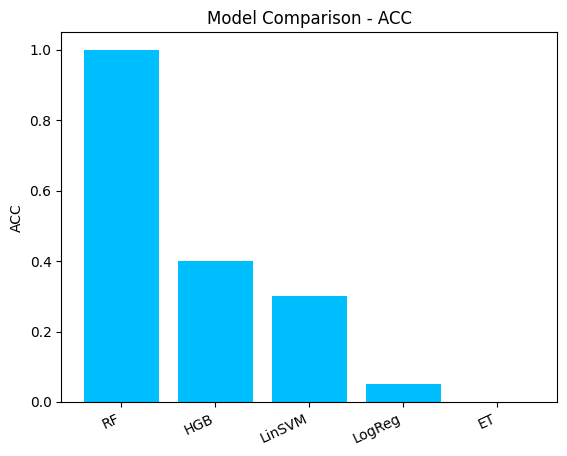

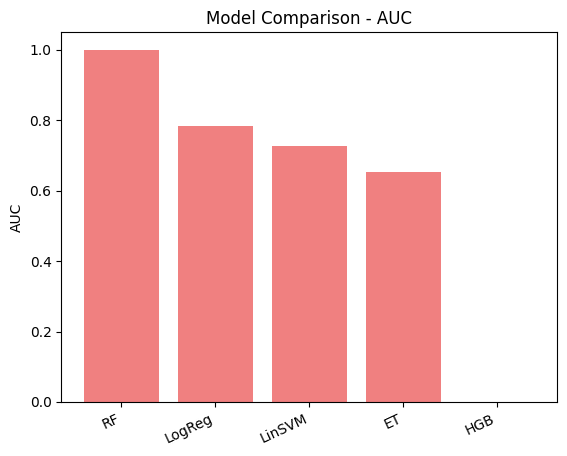

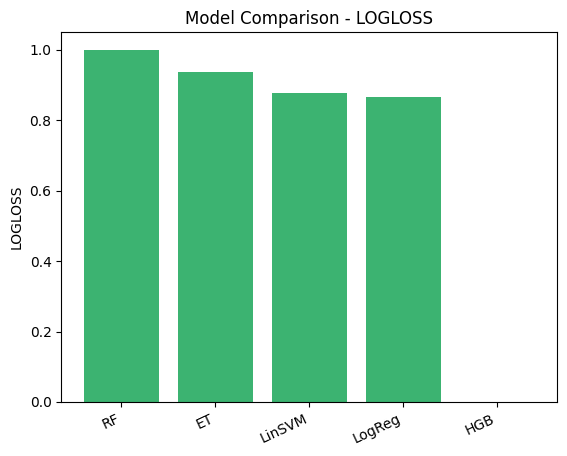

In [ ]:
results = {
    "LogReg": {"acc": 0.5437262357414449, "auc": 0.6030736312509939, "logloss": 0.6817993683513586},
    "LinSVM": {"acc": 0.5532319391634981, "auc": 0.6001821625294568, "logloss": 0.680909098733219},
    "RF": {"acc": 0.5798479087452472, "auc": 0.6136419494282122, "logloss": 0.6724599832794818},
    "ET": {"acc": 0.5418250950570342, "auc": 0.5965967413147507, "logloss": 0.676859559815859},
    "HGB": {"acc": 0.5570342205323194, "auc": 0.5645158958492966, "logloss": 0.7419462284321101}
  }

def barplot(metric, higher_is_better=True, scale=True, color=None):
  items= [(name, results[name][metric]) for name in results] # selecting name, metric wanted
  items = sorted(items, key=lambda x: x[1], reverse=higher_is_better) # reversing the order

  names = [x[0] for x in items]
  vals = np.array([x[1] for x in items], dtype=float) # converting the list to np.array so we can call .min() and .max()

  if scale:
    min, max = vals.min(), vals.max()
    vals = (vals-min)/(max-min + 1e-12) #

    # if lower is better (logloss), invert
    if not higher_is_better:
      vals = 1-vals

    ylabel = f"{metric.upper()} (scaled 0-1)"
  else:
    ylabel = metric.upper()

  order = np.argsort(vals)[::-1] # descending numpy array
  names = [names[i] for i in order]
  vals = vals[order]

  plt.figure()
  plt.bar(names, vals, color=color)
  plt.title(f"Model Comparison - {metric.upper()}")
  plt.ylabel(metric.upper())
  plt.xticks(rotation=25, ha="right")
  plt.show()

# showing the bar plots
barplot("acc", higher_is_better=True, scale=True, color="deepskyblue")
barplot("auc", higher_is_better=True, scale=True, color="lightcoral")
barplot("logloss", higher_is_better=False, scale=True, color="mediumseagreen")

**Note**: Its clear that the best model is the RandomForestClassifier, so we will proceed with that as we continue to upgrade the parameters

# Creating Cleaner leakage-safe CV Pipeline

Currently we are training the model based on aggregated data. When it is trained based off of the prior games, it might've leaked some data as the game we're trying to predict is embedded into the aggregation for the training data, leading the model to potentially learn unrealistic patterns.

In [ ]:
# building the feature columns
use_col = [
    "GP_train",
    "xg_share_train",
    "xg_per_shot_for_shrunk_train",
    "xg_per_shot_against_shrunk_train",
    "shooting_pct_shrunk_train",
    "save_pct_proxy_shrunk_train",
    "pace_per60_train",
    "pim_diff_per60_train",
]
feature_cols = ["is_home"] + [f"delta_{c}" for c in use_col]

In [ ]:
def build_fold(train_df: pd.DataFrame,
                  val_df: pd.DataFrame,
                  use_col: list[str],
                  feature_cols: list[str],
                  k_shots: int = 200,
                  one_row_per_game: bool=False)-> tuple[pd.DataFrame, pd.Series, pd.DataFrame, pd.Series]:
  """
  Build fold-safe features:
    - strength metrics computed from train_df only
    - merge onto train_df and eval_df
    - deltas computed
    - final matrices returned
  """

  train = train_df.copy()
  val = val_df.copy()

  if one_row_per_game:
    train = train[train["is_home"] == 1].copy()
    val = val[val["is_home"]==1].copy()

  # 1) BUILD STRENGTH from training data
  strength = build_strength_metrics(train_df = train, k_shots = 200)

  # 2) Merge strengths from train only
  train_feat = merge_team_and_opp_strength(train, strength)
  val_feat = merge_team_and_opp_strength(val, strength)

  # 3) add deltas (must be applied to both)
  train_feat = add_deltas(train_feat, use_col)
  val_feat = add_deltas(val_feat, use_col)

  # 4) Build X/y
  X_train = train_feat[feature_cols].copy()
  y_train = train_feat["win"].copy()
  X_val = val_feat[feature_cols].copy()
  y_val = val_feat["win"].copy()

  return X_train, y_train, X_val, y_val

In [ ]:
from sklearn.model_selection import GroupKFold
from sklearn.metrics import roc_auc_score, log_loss, accuracy_score
from sklearn.base import clone

def grouped_cv_evaluate(df: pd.DataFrame,
                        models: dict,
                        use_col: list[str],
                        feature_cols: list[str],
                        n_splits: int = 5,
                        k_shots: int = 200,
                        one_row_per_game: bool = False,
                        random_state: int = 42) -> dict:
  """
  Grouped CV by game_id. Rebuilds strength metrics inside each fold (leakage-safe)
  """
  gkf = GroupKFold(n_splits=n_splits)

  X_dummy = df.index.values
  y = df["win"].values
  groups = df["game_id"].values

  results = {name: {"acc": [], "auc": [], "logloss": []} for name in models}

  for fold_i, (train_idx, val_idx) in enumerate(gkf.split(X_dummy, y, groups=groups), start=1):
    train_fold = df.iloc[train_idx].copy()
    val_fold = df.iloc[val_idx].copy()

    # sanity: no game overlap
    overlap = set(train_fold["game_id"]).intersection(set(val_fold["game_id"]))
    if len(overlap) != 0:
      raise ValueError(f"Leakage: fold {fold_i} has game_id overlap = {len(overlap)}")

    X_train, y_train, X_val, y_val = build_fold(
        train_df = train_fold,
        val_df = val_fold,
        use_col = use_col,
        k_shots = k_shots,
        feature_cols = feature_cols,
        one_row_per_game = one_row_per_game
    )

    for name, model in models.items():
      m = clone(model)
      m.fit(X_train, y_train)

      proba = m.predict_proba(X_val)[:, 1] # getting prediction probabilites of each game
      pred = (proba >= 0.5).astype(int) # getting predictions that are correct

      results[name]["acc"].append(accuracy_score(y_val, pred))
      results[name]["auc"].append(roc_auc_score(y_val, proba))
      results[name]["logloss"].append(log_loss(y_val, proba, labels=[0, 1]))

    results_mean = {}
  for name in results: # looping thorugh each model
    results_mean[name] = { # assigning the model with all its mean_score info
        "acc": float(np.mean(results[name]["acc"])),
        "auc": float(np.mean(results[name]["auc"])),
        "logloss": float(np.mean(results[name]["logloss"])),

        # keep folds for debug
        # "acc_folds": results[name]["acc"],
        # "auc_folds": results[name]["auc"],
        # "logloss_folds": results[name]["logloss"],
    }

  return results_mean


# -------------------------
# Example usage:
# results = run_grouped_cv_unshuffled(
#     df=df,
#     models=models,          # {"LogReg": logreg, "RF": rf, ...}
#     use_col=use_col,
#     feature_cols=feature_cols,
#     n_splits=5,
#     k_shots=200,
#     one_row_per_game=False
# )
# results

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

LogisticReg = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=2000))
])

In [ ]:
from sklearn.ensemble import RandomForestClassifier

RandomForestCLF = RandomForestClassifier(
    n_estimators=800,
    max_depth=10,
    min_samples_leaf=20,
    class_weight="balanced_subsample",
    random_state=42,
    n_jobs=-1
)

In [ ]:
from sklearn.linear_model import LogisticRegression

RidgeLogisticReg = LogisticRegression(
    penalty="l2",          # Ridge / L2
    C=1.0,                 # smaller C = stronger regularization
    solver="lbfgs",        # good default for L2
    max_iter=2000,
    class_weight="balanced",
    n_jobs=None            # lbfgs ignores n_jobs; leave None
)

In [ ]:
from sklearn.ensemble import ExtraTreesClassifier

ExtraTreesCLF = ExtraTreesClassifier(
    n_estimators=1500,
    max_depth=None,
    min_samples_leaf=15,
    max_features="sqrt",
    class_weight="balanced_subsample",
    random_state=42,
    n_jobs=-1
)

In [ ]:
from sklearn.ensemble import HistGradientBoostingClassifier

HistGradientBoostCLF = HistGradientBoostingClassifier(
    max_depth=3,
    learning_rate=0.03,
    max_iter=1200,
    min_samples_leaf=40,
    l2_regularization=1.0,
    random_state=42
)

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

models = {
    "LogisticReg": LogisticReg,
    "ExtraTreesClassifier": ExtraTreesCLF,
    "RidgeLogisticReg": RidgeLogisticReg,
    "RandomForestCLF": RandomForestCLF,
    "HistGradientBoostCLF": HistGradientBoostCLF
}

In [ ]:
results = grouped_cv_evaluate(
    df = df,
    models = models,
    use_col = use_col,
    feature_cols = feature_cols,
    n_splits = 5,
    k_shots = 200,
    one_row_per_game=False
)
results

{'LogisticReg': {'acc': 0.569378573709111,
  'auc': 0.6152966609798223,
  'logloss': 0.674359567506397},
 'ExtraTreesClassifier': {'acc': 0.5888122950105942,
  'auc': 0.6124312817357426,
  'logloss': 0.673584456941107},
 'RidgeLogisticReg': {'acc': 0.583092909180623,
  'auc': 0.6086832693645934,
  'logloss': 0.6755170048659678},
 'RandomForestCLF': {'acc': 0.5586930020607784,
  'auc': 0.5922355230859881,
  'logloss': 0.6839560460834911},
 'HistGradientBoostCLF': {'acc': 0.5312614286128929,
  'auc': 0.5590346071190421,
  'logloss': 0.7457461082612808}}

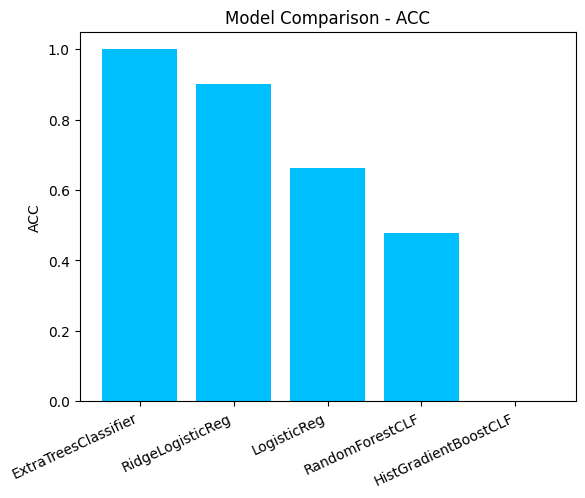

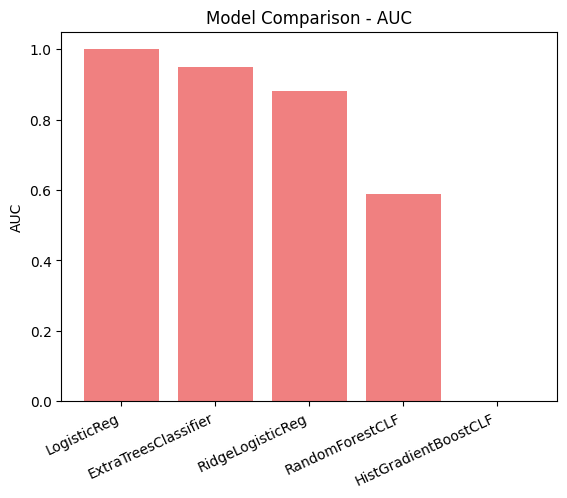

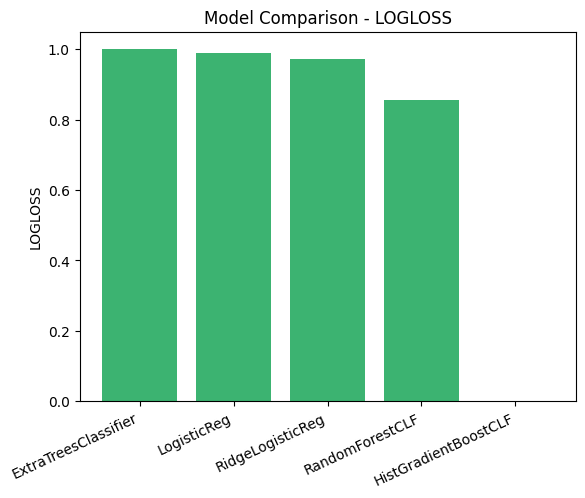

In [ ]:
# showing the bar plots
barplot("acc", higher_is_better=True, scale=True, color="deepskyblue")
barplot("auc", higher_is_better=True, scale=True, color="lightcoral")
barplot("logloss", higher_is_better=False, scale=True, color="mediumseagreen")

Turns out after CV, the RandomForestClassifier isn't actually the best!

# 5v5 Upgrade

We can repeat the steps for EDA that we took in order to get the 5v5 games.

We can also add the goalie metrics.

In [ ]:
og_df = pd.read_csv("/content/drive/MyDrive/Wharton Data Science Competition 2026/whl_2025.csv")

off_5v5 = {"first_off", "second_off"}
def_5v5 = {"first_def", "second_def"}

mask = (
    og_df["home_off_line"].isin(off_5v5) &
    og_df["home_def_pairing"].isin(def_5v5) &
    og_df["away_off_line"].isin(off_5v5) &
    og_df["away_def_pairing"].isin(def_5v5)
)

game_5v5 = og_df.loc[mask].copy()
game_5v5.head()

,game_id,record_id,home_team,away_team,went_ot,home_off_line,home_def_pairing,away_off_line,away_def_pairing,home_goalie,...,home_goals,away_assists,away_shots,away_xg,away_max_xg,away_goals,home_penalties_committed,home_penalty_minutes,away_penalties_committed,away_penalty_minutes
1,game_1,record_2,thailand,pakistan,0,second_off,second_def,second_off,second_def,player_id_142,...,0,2,1,0.0928,0.0928,1,0,0,0,0
2,game_1,record_3,thailand,pakistan,0,first_off,second_def,second_off,second_def,player_id_142,...,0,0,2,0.1880,0.0940,0,0,0,0,0
3,game_1,record_4,thailand,pakistan,0,second_off,first_def,second_off,first_def,player_id_142,...,0,0,1,0.0727,0.0727,0,0,0,0,0
4,game_1,record_5,thailand,pakistan,0,second_off,second_def,first_off,second_def,player_id_142,...,0,2,1,0.0769,0.0769,1,0,0,0,0
6,game_1,record_7,thailand,pakistan,0,first_off,first_def,first_off,first_def,player_id_142,...,0,0,1,0.0928,0.0928,0,0,0,0,0


After getting only the 5v5 games, it turns out that there are almost exactly 16 record_ids for every single game!

In [ ]:
game_5v5["game_id"].value_counts().describe()

,count
count,1312.000000
mean,15.999238
std,0.027608
min,15.000000
25%,16.000000
50%,16.000000
75%,16.000000
max,16.000000


In [ ]:
# aggregate data
agg_dict = {
    # identifiers
    "home_team": "first",
    "away_team": "first",

    # Numerical (sum)
    "toi": "sum",
    "home_goals": "sum",
    "away_goals": "sum",
    "home_assists": "sum",
    "away_assists": "sum",
    "home_shots": "sum",
    "away_shots": "sum",
    "home_xg": "sum",
    "away_xg": "sum",
    "home_penalties_committed": "sum",
    "away_penalties_committed": "sum",
    "home_penalty_minutes": "sum",
    "away_penalty_minutes": "sum"
}

## as_index=False is keeping game_id as normal column in the output
game_5v5_agg = game_5v5.groupby("game_id", as_index=False).agg(agg_dict)
# game_5v5_agg.to_csv("/content/drive/MyDrive/Wharton Data Science Competition 2026/game_5v5_agg.csv")
game_5v5_agg

,game_id,home_team,away_team,toi,home_goals,away_goals,home_assists,away_assists,home_shots,away_shots,home_xg,away_xg,home_penalties_committed,away_penalties_committed,home_penalty_minutes,away_penalty_minutes
0,game_1,thailand,pakistan,2266.64,1,2,2,4,9,12,1.0375,1.0560,0,0,0,0
1,game_10,switzerland,kazakhstan,2564.60,4,1,7,0,19,16,1.8248,1.2294,0,0,0,0
2,game_100,serbia,rwanda,2253.06,2,0,3,0,19,15,2.0422,1.2885,0,0,0,0
3,game_1000,brazil,netherlands,2494.92,5,0,6,0,25,17,2.6271,1.2009,0,1,0,2
4,game_1001,india,morocco,2288.12,2,1,4,2,18,14,1.7419,1.3640,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1307,game_995,vietnam,mexico,2727.25,2,1,2,0,22,14,1.9923,1.2992,0,0,0,0
1308,game_996,kazakhstan,indonesia,2640.00,0,3,0,4,10,16,1.0312,1.4714,0,0,0,0
1309,game_997,canada,south_korea,2332.07,3,1,5,2,15,20,1.4710,1.7109,0,0,0,0
1310,game_998,switzerland,uae,2280.31,1,1,1,1,18,13,1.3009,1.3394,1,0,2,0


In [ ]:
# creating separate home/away dataframes then concatenating them
home = pd.DataFrame({
    "game_id": game_5v5_agg["game_id"],
    "team": game_5v5_agg["home_team"],
    "opponent": game_5v5_agg["away_team"],
    "toi": game_5v5_agg["toi"],
    "is_home": 1,

    "goals_for": game_5v5_agg["home_goals"],
    "goals_against": game_5v5_agg["away_goals"],

    "assists_for": game_5v5_agg["home_assists"],
    "assists_against": game_5v5_agg["away_assists"],

    "shots_for": game_5v5_agg["home_shots"],
    "shots_against": game_5v5_agg["away_shots"],

    "xg_for": game_5v5_agg["home_xg"],
    "xg_against": game_5v5_agg["away_xg"],

    "pens_committed_for": game_5v5_agg["home_penalties_committed"],
    "pens_committed_against": game_5v5_agg["away_penalties_committed"],

    "pim_for": game_5v5_agg["home_penalty_minutes"],
    "pim_against": game_5v5_agg["away_penalty_minutes"]
})

# creating separate home/away dataframes then concatenating them
away = pd.DataFrame({
    "game_id": game_5v5_agg["game_id"],
    "team": game_5v5_agg["away_team"],
    "opponent": game_5v5_agg["home_team"],
    "toi": game_5v5_agg["toi"],
    "is_home": 0,

    "goals_for": game_5v5_agg["away_goals"],
    "goals_against": game_5v5_agg["home_goals"],

    "assists_for": game_5v5_agg["away_assists"],
    "assists_against": game_5v5_agg["home_assists"],

    "shots_for": game_5v5_agg["away_shots"],
    "shots_against": game_5v5_agg["home_shots"],

    "xg_for": game_5v5_agg["away_xg"],
    "xg_against": game_5v5_agg["home_xg"],

    "pens_committed_for": game_5v5_agg["away_penalties_committed"],
    "pens_committed_against": game_5v5_agg["home_penalties_committed"],

    "pim_for": game_5v5_agg["away_penalty_minutes"],
    "pim_against": game_5v5_agg["home_penalty_minutes"]
})

game_5v5_combo = pd.concat([home, away], ignore_index=True) # ignore_index means create an entirely new DataFrame structure
game_5v5_combo

,game_id,team,opponent,toi,is_home,goals_for,goals_against,assists_for,assists_against,shots_for,shots_against,xg_for,xg_against,pens_committed_for,pens_committed_against,pim_for,pim_against
0,game_1,thailand,pakistan,2266.64,1,1,2,2,4,9,12,1.0375,1.0560,0,0,0,0
1,game_10,switzerland,kazakhstan,2564.60,1,4,1,7,0,19,16,1.8248,1.2294,0,0,0,0
2,game_100,serbia,rwanda,2253.06,1,2,0,3,0,19,15,2.0422,1.2885,0,0,0,0
3,game_1000,brazil,netherlands,2494.92,1,5,0,6,0,25,17,2.6271,1.2009,0,1,0,2
4,game_1001,india,morocco,2288.12,1,2,1,4,2,18,14,1.7419,1.3640,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2619,game_995,mexico,vietnam,2727.25,0,1,2,0,2,14,22,1.2992,1.9923,0,0,0,0
2620,game_996,indonesia,kazakhstan,2640.00,0,3,0,4,0,16,10,1.4714,1.0312,0,0,0,0
2621,game_997,south_korea,canada,2332.07,0,1,3,2,5,20,15,1.7109,1.4710,0,0,0,0
2622,game_998,uae,switzerland,2280.31,0,1,1,1,1,13,18,1.3394,1.3009,0,1,0,2


In [ ]:
game_5v5_combo["win"] = (game_5v5_combo["goals_for"] > game_5v5_combo["goals_against"]).astype(int)
game_5v5_combo.sort_values("game_id")

,game_id,team,opponent,toi,is_home,goals_for,goals_against,assists_for,assists_against,shots_for,shots_against,xg_for,xg_against,pens_committed_for,pens_committed_against,pim_for,pim_against,win
0,game_1,thailand,pakistan,2266.64,1,1,2,2,4,9,12,1.0375,1.0560,0,0,0,0,0
1312,game_1,pakistan,thailand,2266.64,0,2,1,4,2,12,9,1.0560,1.0375,0,0,0,0,1
1313,game_10,kazakhstan,switzerland,2564.60,0,1,4,0,7,16,19,1.2294,1.8248,0,0,0,0,0
1,game_10,switzerland,kazakhstan,2564.60,1,4,1,7,0,19,16,1.8248,1.2294,0,0,0,0,1
2,game_100,serbia,rwanda,2253.06,1,2,0,3,0,19,15,2.0422,1.2885,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1309,game_997,canada,south_korea,2332.07,1,3,1,5,2,15,20,1.4710,1.7109,0,0,0,0,1
2622,game_998,uae,switzerland,2280.31,0,1,1,1,1,13,18,1.3394,1.3009,0,1,0,2,0
1310,game_998,switzerland,uae,2280.31,1,1,1,1,1,18,13,1.3009,1.3394,1,0,2,0,0
1311,game_999,oman,thailand,2600.37,1,0,1,0,2,22,13,2.0556,1.4105,0,0,0,0,0


In [ ]:
# Export to csv
# game_5v5_combo.to_csv("/content/drive/MyDrive/Wharton Data Science Competition 2026/game_5v5_combo.csv")

In [ ]:
results = grouped_cv_evaluate(
    df = df,
    models = models,
    use_col = use_col,
    feature_cols = feature_cols,
    n_splits = 5,
    k_shots = 200,
    one_row_per_game=False
)
results

{'LogisticReg': {'acc': 0.569378573709111,
  'auc': 0.6152966609798223,
  'logloss': 0.674359567506397},
 'ExtraTreesClassifier': {'acc': 0.5888122950105942,
  'auc': 0.6124312817357426,
  'logloss': 0.673584456941107},
 'RidgeLogisticReg': {'acc': 0.583092909180623,
  'auc': 0.6086832693645934,
  'logloss': 0.6755170048659678},
 'RandomForestCLF': {'acc': 0.5586930020607784,
  'auc': 0.5922355230859881,
  'logloss': 0.6839560460834911},
 'HistGradientBoostCLF': {'acc': 0.5312614286128929,
  'auc': 0.5590346071190421,
  'logloss': 0.7457461082612808}}

In [ ]:
results2 = grouped_cv_evaluate(
    df = game_5v5_combo,
    models = models,
    use_col = use_col,
    feature_cols = feature_cols,
    n_splits = 5,
    k_shots = 200,
    one_row_per_game=False
)
results2

{'LogisticReg': {'acc': 0.6185223347749107,
  'auc': 0.6019670674514168,
  'logloss': 0.6552076391222491},
 'ExtraTreesClassifier': {'acc': 0.5709023887615011,
  'auc': 0.599448562420721,
  'logloss': 0.6758716931190527},
 'RidgeLogisticReg': {'acc': 0.5666952079644734,
  'auc': 0.5957785156113935,
  'logloss': 0.678448397645029},
 'RandomForestCLF': {'acc': 0.5842335935912694,
  'auc': 0.5972456306231504,
  'logloss': 0.6759834708017116},
 'HistGradientBoostCLF': {'acc': 0.5884248106115578,
  'auc': 0.5750502273916184,
  'logloss': 0.7058523079877146}}

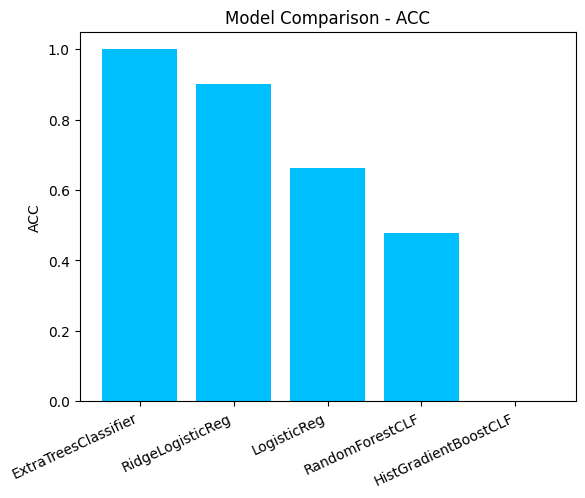

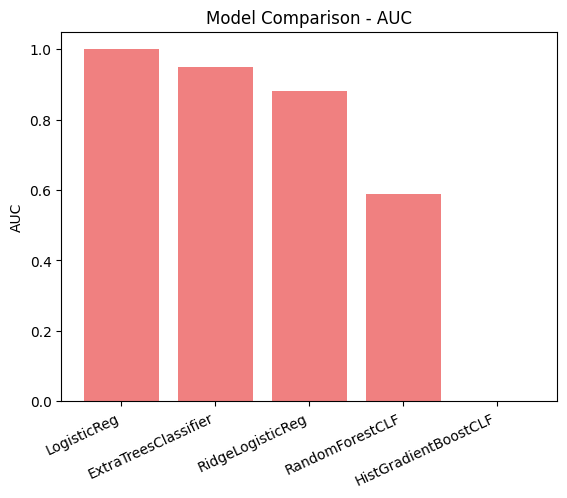

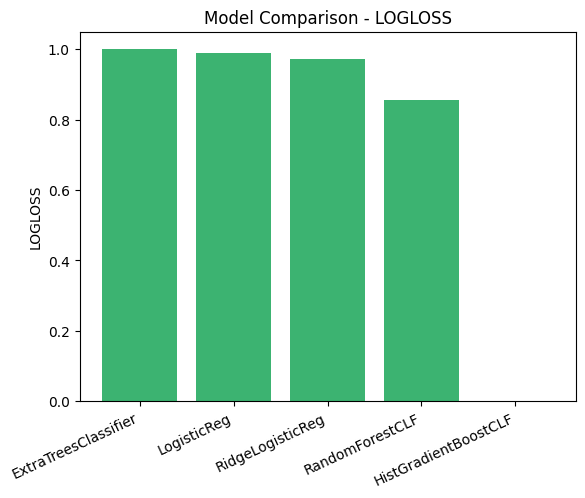

In [ ]:
# showing the bar plots
barplot("acc", higher_is_better=True, scale=True, color="deepskyblue")
barplot("auc", higher_is_better=True, scale=True, color="lightcoral")
barplot("logloss", higher_is_better=False, scale=True, color="mediumseagreen")

## Creating Hyperparameter Pipeline

Re-using our initial pipeline but this time hyperparameter-tuning it and putting it back into our model.

In [ ]:
from sklearn.model_selection import GroupKFold, ParameterGrid
from sklearn.base import clone
from sklearn.metrics import log_loss
import numpy as np

def grid_search_with_build_fold(df, use_col, feature_cols,
                                estimator, param_grid,
                                n_splits=3, k_shots=200, one_row_per_game=False):
    gkf = GroupKFold(n_splits=n_splits)
    groups = df["game_id"].values

    best_params, best_score = None, np.inf  # minimize logloss

    for params in ParameterGrid(param_grid):
        fold_losses = []

        for tr_idx, va_idx in gkf.split(df, groups=groups):
            tr_df = df.iloc[tr_idx].copy()
            va_df = df.iloc[va_idx].copy()

            X_tr, y_tr, X_va, y_va = build_fold(
                train_df=tr_df,
                val_df=va_df,
                use_col=use_col,
                feature_cols=feature_cols,
                k_shots=k_shots,
                one_row_per_game=one_row_per_game
            )

            model = clone(estimator).set_params(**params)
            model.fit(X_tr, y_tr)

            proba = model.predict_proba(X_va)[:, 1]
            fold_losses.append(log_loss(y_va, proba, labels=[0, 1]))

        mean_loss = float(np.mean(fold_losses))
        if mean_loss < best_score:
            best_score = mean_loss
            best_params = params

    return best_params, best_score

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer
from sklearn.ensemble import ExtraTreesClassifier

identity = FunctionTransformer(lambda X: X, feature_names_out="one-to-one")

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

pipe_lr = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(
        max_iter=2000,
        solver="lbfgs",   # stable default for L2
        penalty="l2"
    ))
])

param_grid_lr = {
    # very wide log grid for regularization strength
    "clf__C": [
        1e-6, 3e-6, 1e-5, 3e-5,
        1e-4, 3e-4, 1e-3, 3e-3,
        1e-2, 3e-2, 1e-1, 3e-1,
        1, 3, 10, 30, 100, 300, 1000
    ],

    # handle imbalance if needed
    "clf__class_weight": [None, "balanced"],

    # convergence / stability knobs (rarely change the optimum but help robustness)
    "clf__tol": [1e-5, 1e-4, 1e-3],
}

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer
from sklearn.ensemble import ExtraTreesClassifier

identity = FunctionTransformer(lambda X: X, feature_names_out="one-to-one")

pipe_et = Pipeline([
    ("id", identity),
    ("clf", ExtraTreesClassifier(
        random_state=42,
        n_jobs=-1
    ))
])

param_grid_et = {
    "clf__n_estimators": [400, 800],
    "clf__max_depth": [None, 14, 20],
    "clf__min_samples_leaf": [2, 4, 8],      # helps logloss vs overconfidence
    "clf__max_features": ["sqrt", 0.8],
}

In [ ]:
# best_lr_params, best_lr_loss = grid_search_with_build_fold(
#     df=game_5v5_combo,
#     use_col=use_col,
#     feature_cols=feature_cols,
#     estimator=pipe_lr,
#     param_grid=param_grid_lr,
#     n_splits=5,
#     k_shots=200,
#     one_row_per_game=False
# )
# print("LR best:", best_lr_params, best_lr_loss)

In [ ]:
# best_et_params, best_et_loss = grid_search_with_build_fold(
#     df=game_5v5_combo,
#     use_col=use_col,
#     feature_cols=feature_cols,
#     estimator=pipe_et,
#     param_grid=param_grid_et,
#     n_splits=5,
#     k_shots=200,
#     one_row_per_game=False
# )
# print("ET best:", best_et_params, best_et_loss)

In [ ]:
# Comparing previously, untuned models (that were pretty good)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

LogisticReg = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=2000))
])

In [ ]:
# regular ExtraTreesCLF
from sklearn.ensemble import ExtraTreesClassifier

ExtraTreesCLF = ExtraTreesClassifier(
    n_estimators=1500,
    max_depth=None,
    min_samples_leaf=15,
    max_features="sqrt",
    class_weight="balanced_subsample",
    random_state=42,
    n_jobs=-1
)

In [ ]:
best_params_lr = {'clf__C': 0.01, 'clf__class_weight': None, 'clf__tol': 0.001}
best_params_et = {'clf__max_depth': None, 'clf__max_features': 'sqrt', 'clf__min_samples_leaf': 8, 'clf__n_estimators': 400}

tuned_lr = clone(LogisticReg).set_params(**best_params_lr)
tuned_et = clone(pipe_et).set_params(**best_params_et)
models = {"LR_tuned": tuned_lr,
          "ET_tuned": tuned_et,
          "Extra_tree": ExtraTreesCLF,
          "LR_untuned":LogisticReg}

results = grouped_cv_evaluate(
    df = game_5v5_combo,
    models = models,
    use_col = use_col,
    feature_cols = feature_cols,
    n_splits = 5, # changing from 5 to 3, seems like a better result
    k_shots = 200,
    one_row_per_game=False
)
results

{'LR_tuned': {'acc': 0.6192842423011058,
  'auc': 0.6019395799149224,
  'logloss': 0.6532555557918671},
 'ET_tuned': {'acc': 0.6124212695556265,
  'auc': 0.5982261602186442,
  'logloss': 0.6537512701617614},
 'Extra_tree': {'acc': 0.5709023887615011,
  'auc': 0.599448562420721,
  'logloss': 0.6758716931190527},
 'LR_untuned': {'acc': 0.6185223347749107,
  'auc': 0.6019670674514168,
  'logloss': 0.6552076391222491}}

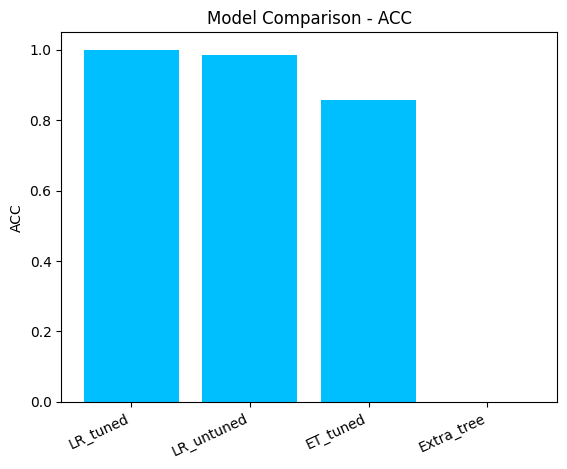

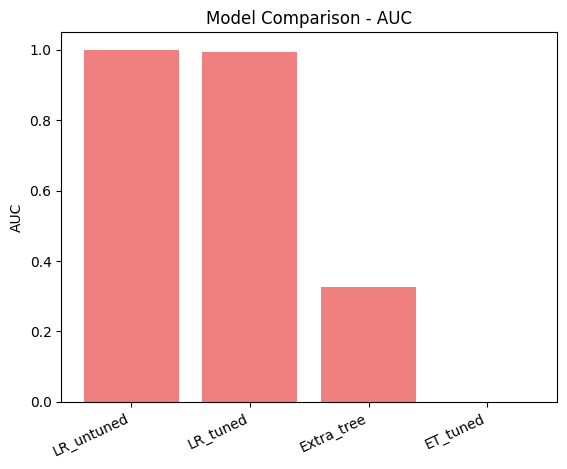

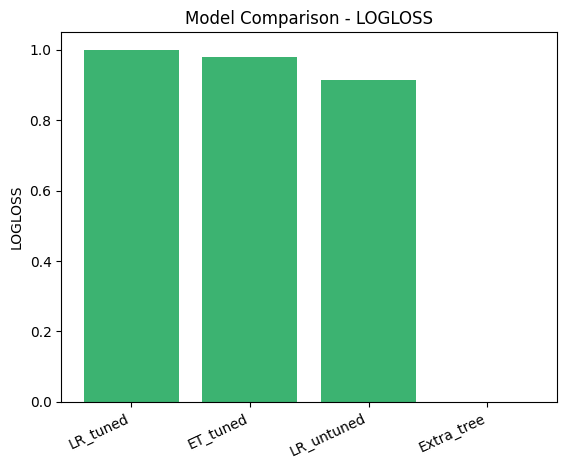

In [ ]:
# showing the bar plots
barplot("acc", higher_is_better=True, scale=True, color="deepskyblue")
barplot("auc", higher_is_better=True, scale=True, color="lightcoral")
barplot("logloss", higher_is_better=False, scale=True, color="mediumseagreen")

## Clearly, LR_tuned is the best in every category so we will be using that to predict round 1 games

In [ ]:
train_df = game_5v5_combo.copy()

# sanity checks
assert "win" in train_df.columns
assert "game_id" in train_df.columns
assert "team" in train_df.columns
assert "is_home" in train_df.columns

In [ ]:
# build train features using Train-derived strength

# train 2 one home and away but only test on home
train = train_df.copy()

# making sure that strength is built from the 1 row columns
strength = build_strength_metrics(train_df=train, k_shots=200)

train_feat = merge_team_and_opp_strength(train, strength)
train_feat = add_deltas(train_feat, use_col)

X_train = train_feat[feature_cols].copy()
y_train = train_feat["win"].astype(int).copy()

# fit model
final_model = clone(tuned_lr).fit(X_train, y_train)

In [ ]:
matchup = pd.read_excel("/content/drive/MyDrive/Wharton Data Science Competition 2026/WHSDSC_Rnd1_matchups.xlsx")
matchup

,game,game_id,home_team,away_team
0,1,game_1,brazil,kazakhstan
1,2,game_2,netherlands,mongolia
2,3,game_3,peru,rwanda
3,4,game_4,thailand,oman
4,5,game_5,pakistan,germany
5,6,game_6,india,usa
6,7,game_7,panama,switzerland
7,8,game_8,iceland,canada
8,9,game_9,china,france
9,10,game_10,philippines,morocco


In [ ]:
# Two-row-per-game format (team perspective)
pred_df = matchup.assign(team=matchup["home_team"], opponent=matchup["away_team"], is_home=1)
pred_df = pred_df.drop(columns=["home_team", "away_team", "game"])
pred_df

,game_id,team,opponent,is_home
0,game_1,brazil,kazakhstan,1
1,game_2,netherlands,mongolia,1
2,game_3,peru,rwanda,1
3,game_4,thailand,oman,1
4,game_5,pakistan,germany,1
5,game_6,india,usa,1
6,game_7,panama,switzerland,1
7,game_8,iceland,canada,1
8,game_9,china,france,1
9,game_10,philippines,morocco,1


In [ ]:
# refresher on what it looks like
feature_cols

['is_home',
 'delta_GP_train',
 'delta_xg_share_train',
 'delta_xg_per_shot_for_shrunk_train',
 'delta_xg_per_shot_against_shrunk_train',
 'delta_shooting_pct_shrunk_train',
 'delta_save_pct_proxy_shrunk_train',
 'delta_pace_per60_train',
 'delta_pim_diff_per60_train']

In [ ]:
# Build features for matchups using TRAIN-derived strength metrics
pred_feat = merge_team_and_opp_strength(pred_df, strength)
pred_feat = add_deltas(pred_feat, use_col)

X_pred = pred_feat[feature_cols].copy()

# predicted prob that THIS ROW's team wins
pred_feat["p_win"] = final_model.predict_proba(X_pred)[:, 1]
pred_feat

,game_id,team,opponent,is_home,team_GP_train,team_xg_share_train,team_xg_per_shot_for_shrunk_train,team_xg_per_shot_against_shrunk_train,team_shooting_pct_shrunk_train,team_save_pct_proxy_shrunk_train,...,delta_GP_train,delta_xg_share_train,delta_xg_per_shot_for_shrunk_train,delta_xg_per_shot_against_shrunk_train,delta_shooting_pct_shrunk_train,delta_save_pct_proxy_shrunk_train,delta_pace_per60_train,delta_pim_diff_per60_train,min_GP_train,p_win
0,game_1,brazil,kazakhstan,1,82,0.594313,0.110714,0.081517,0.115137,0.928281,...,0,0.174451,0.026170,-0.021847,0.032484,0.039467,5.555459,0.033968,82,0.707706
1,game_2,netherlands,mongolia,1,82,0.516721,0.094370,0.086969,0.092056,0.923430,...,0,0.133486,0.016600,-0.013885,0.012060,0.020832,-3.200217,0.063543,82,0.584132
2,game_3,peru,rwanda,1,82,0.525343,0.089767,0.092207,0.092756,0.917789,...,0,0.023923,-0.001430,-0.003432,0.009629,0.014711,0.086986,0.004822,82,0.505741
3,game_4,thailand,oman,1,82,0.594557,0.111668,0.088742,0.114060,0.904476,...,0,0.077643,0.011736,-0.011692,0.014934,0.009560,-0.318905,-0.204221,82,0.522865
4,game_5,pakistan,germany,1,82,0.586418,0.102066,0.098205,0.105457,0.903777,...,0,0.116708,0.002014,-0.007827,-0.004797,0.016123,4.035009,0.282021,82,0.546652
5,game_6,india,usa,1,82,0.497352,0.085980,0.093681,0.086518,0.930151,...,0,0.019083,-0.012071,-0.005713,-0.017199,0.036269,1.142612,0.099251,82,0.512634
6,game_7,panama,switzerland,1,82,0.495718,0.098194,0.097846,0.093476,0.915419,...,0,0.026876,0.014314,0.008068,0.007324,0.003230,2.593730,-0.065526,82,0.456805
7,game_8,iceland,canada,1,82,0.498456,0.097687,0.092167,0.106229,0.922444,...,0,-0.013365,0.003019,-0.005036,0.020805,0.034460,0.077707,0.354816,82,0.545012
8,game_9,china,france,1,82,0.541671,0.104544,0.086555,0.097925,0.919422,...,0,0.059961,0.006403,-0.017015,0.007107,0.041795,1.840774,0.001733,82,0.587050
9,game_10,philippines,morocco,1,82,0.441219,0.086425,0.096642,0.079971,0.926173,...,0,-0.066982,-0.006062,0.012606,-0.003177,0.021970,-6.492866,-0.158226,82,0.434680


In [ ]:
round1_winners = pred_feat[["game_id", "team", "opponent", "p_win"]]
round1_winners

,game_id,team,opponent,p_win
0,game_1,brazil,kazakhstan,0.707706
1,game_2,netherlands,mongolia,0.584132
2,game_3,peru,rwanda,0.505741
3,game_4,thailand,oman,0.522865
4,game_5,pakistan,germany,0.546652
5,game_6,india,usa,0.512634
6,game_7,panama,switzerland,0.456805
7,game_8,iceland,canada,0.545012
8,game_9,china,france,0.587050
9,game_10,philippines,morocco,0.434680


In [ ]:
# round1_winners.to_csv("/content/drive/MyDrive/Wharton Data Science Competition 2026/winners_proba_home_&_away_training.csv")